Этап 1. Проведите исследовательский анализ (EDA)
Загрузите датасет и визуализируйте часть данных. Изучите то, с чем предстоит работать
Сформируйте видение:
как вы будете решать задачу,
какие подходы к обогащению/аугментации данных примените и почему,
на какие метрики будете ориентироваться при обучении.
Результаты: EDA и выводы о подходах к решению задачи. 

Подготовка DataFrame

In [65]:
!pip install pandas albumentations timm transformers pillow
import pandas as pd

# Загружаем CSV
dish_df = pd.read_csv("data/dish.csv")
ingr_df = pd.read_csv("data/ingredients.csv")

# Словарь: id -> название ингредиента
ingr_map = dict(zip(
    ingr_df["id"].astype(str).str.zfill(10),
    ingr_df["ingr"]
))

def ingredients_to_text(ingr_string):
    ids = ingr_string.split(";")
    names = []
    for ingr_id in ids:
        num_id = ingr_id.replace("ingr_", "")
        if num_id in ingr_map:
            names.append(ingr_map[num_id])
    return ", ".join(names)

# Формируем текст
dish_df["text"] = dish_df["ingredients"].apply(ingredients_to_text)

# Пути к изображениям
dish_df["image_path"] = dish_df["dish_id"].apply(
    lambda x: f"{x}/rgb.png"
)

# Label = калории (REGRESSION!)
dish_df["label"] = dish_df["total_calories"]

# Train / test
train_df = dish_df[dish_df["split"] == "train"].reset_index(drop=True)
test_df  = dish_df[dish_df["split"] == "test"].reset_index(drop=True)


Dataset

In [2]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import timm
from transformers import AutoTokenizer

class MultimodalDataset(Dataset):
    def __init__(self, df, text_model, image_model, transforms):
        self.df = df
        self.image_cfg = timm.get_pretrained_cfg(image_model)
        self.tokenizer = AutoTokenizer.from_pretrained(text_model)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        text = row["text"]
        label = torch.tensor(row["label"], dtype=torch.float32)

        img_path = f"data/images/{row['image_path']}"
        image = Image.open(img_path).convert("RGB")
        image = self.transforms(image=np.array(image))["image"]

        return {
            "text": text,
            "image": image,
            "label": label
        }


c:\Users\Admin\NEIRO\SPR_4_FINAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Collate fn

In [3]:
def collate_fn(batch, tokenizer):
    texts = [item["text"] for item in batch]
    images = torch.stack([item["image"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])

    tokens = tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    return {
        "image": images,
        "input_ids": tokens["input_ids"],
        "attention_mask": tokens["attention_mask"],
        "label": labels
    }


Аугментации

In [4]:
import albumentations as A

image_model = "tf_efficientnet_b0"
cfg = timm.get_pretrained_cfg(image_model)

transforms = A.Compose([
    A.SmallestMaxSize(max_size=max(cfg.input_size[1], cfg.input_size[2])),
    A.RandomCrop(cfg.input_size[1], cfg.input_size[2]),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(0.2, 0.2, 0.2, 0.1, p=0.7),
    A.Normalize(mean=cfg.mean, std=cfg.std),
])


DataLoaders

In [5]:
from torch.utils.data import DataLoader
from functools import partial

text_model = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(text_model)

train_ds = MultimodalDataset(
    train_df,
    text_model=text_model,
    image_model=image_model,
    transforms=transforms
)

test_ds = MultimodalDataset(
    test_df,
    text_model=text_model,
    image_model=image_model,
    transforms=transforms
)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    collate_fn=partial(collate_fn, tokenizer=tokenizer)
)

test_loader = DataLoader(
    test_ds,
    batch_size=8,
    shuffle=False,
    collate_fn=partial(collate_fn, tokenizer=tokenizer)
)


Визуализация данных (EDA)

Распределение калорий (target)

  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp311-cp311-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ------ --------------------------------- 1/6 [kiwisolver]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -

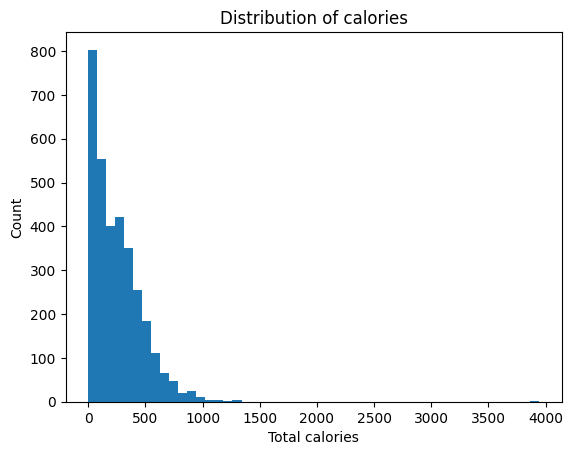

In [7]:
!pip install matplotlib
import matplotlib.pyplot as plt

plt.figure()
plt.hist(dish_df["total_calories"], bins=50)
plt.xlabel("Total calories")
plt.ylabel("Count")
plt.title("Distribution of calories")
plt.show()


Распределение массы блюд

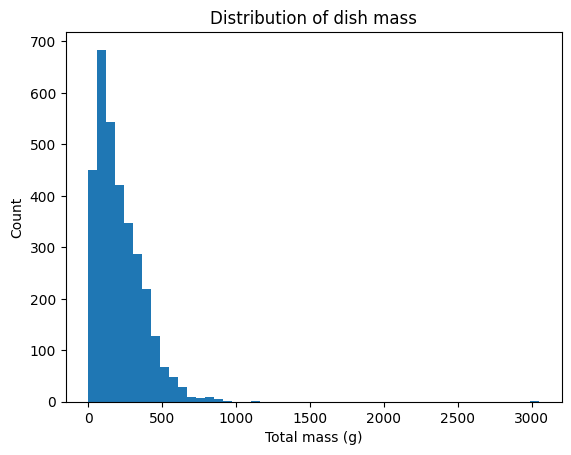

In [8]:
plt.figure()
plt.hist(dish_df["total_mass"], bins=50)
plt.xlabel("Total mass (g)")
plt.ylabel("Count")
plt.title("Distribution of dish mass")
plt.show()


Связь массы и калорий

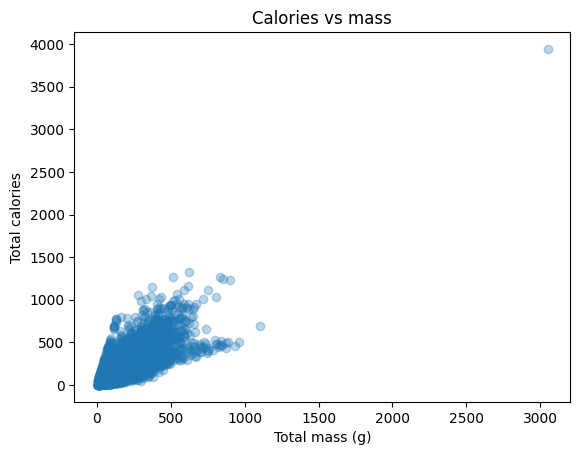

In [9]:
plt.figure()
plt.scatter(
    dish_df["total_mass"],
    dish_df["total_calories"],
    alpha=0.3
)
plt.xlabel("Total mass (g)")
plt.ylabel("Total calories")
plt.title("Calories vs mass")
plt.show()


Количество ингредиентов в блюде

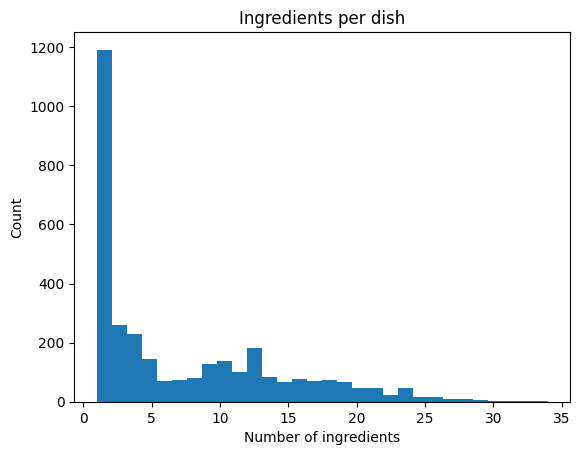

In [10]:
dish_df["num_ingredients"] = dish_df["ingredients"].apply(
    lambda x: len(x.split(";"))
)

plt.figure()
plt.hist(dish_df["num_ingredients"], bins=30)
plt.xlabel("Number of ingredients")
plt.ylabel("Count")
plt.title("Ingredients per dish")
plt.show()


Train / Test распределение

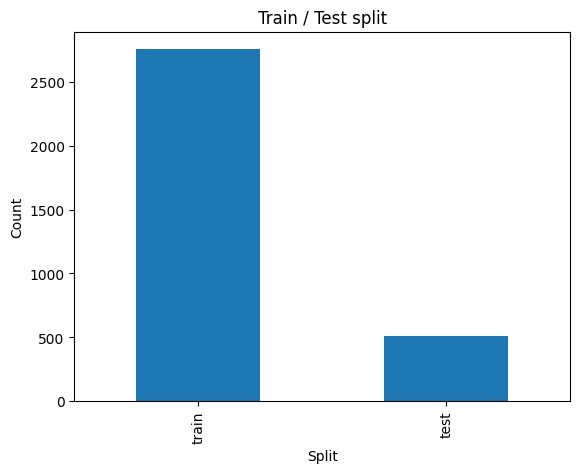

In [11]:
dish_df["split"].value_counts().plot(kind="bar")
plt.xlabel("Split")
plt.ylabel("Count")
plt.title("Train / Test split")
plt.show()


ВЫВОД: калорийность зависит от массы, большая часть блюд имеет множество ингридиентов. Выбросы есть, что подтверждает необходимость нормальлизации

Этап 2. Реализуйте пайплайн обучения

Реализация архитектуры мультимодальной нейросети

In [ ]:
# import torch
# import torch.nn as nn
# import timm
# from transformers import AutoModel


# class MultimodalCalorieModel(nn.Module):
#     def __init__(
#         self,
#         text_model_name="bert-base-uncased",
#         image_model_name="tf_efficientnet_b0",
#         emb_dim=256,
#         dropout=0.1
#     ):
#         super().__init__()

#         # ---- Text encoder ----
#         self.text_model = AutoModel.from_pretrained(text_model_name)
#         text_hidden = self.text_model.config.hidden_size

#         # ---- Image encoder ----
#         self.image_model = timm.create_model(
#             image_model_name,
#             pretrained=True,
#             num_classes=0  # remove classification head
#         )
#         image_hidden = self.image_model.num_features

#         # ---- Projection layers ----
#         self.text_proj = nn.Linear(text_hidden, emb_dim)
#         self.image_proj = nn.Linear(image_hidden, emb_dim)

#         # ---- Fusion head (REGRESSION) ----
#         self.regressor = nn.Sequential(
#             nn.Linear(emb_dim * 2, emb_dim),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(emb_dim, 1)
#         )

#     def forward(
#         self,
#         input_ids,
#         attention_mask,
#         image
#     ):
#         # ---- Text forward ----
#         text_out = self.text_model(
#             input_ids=input_ids,
#             attention_mask=attention_mask
#         )
#         # [CLS] token
#         text_features = text_out.last_hidden_state[:, 0, :]

#         # ---- Image forward ----
#         image_features = self.image_model(image)

#         # ---- Project to shared space ----
#         text_emb = self.text_proj(text_features)
#         image_emb = self.image_proj(image_features)

#         # ---- Concatenation ----
#         fused = torch.cat([text_emb, image_emb], dim=1)

#         # ---- Regression ----
#         calories = self.regressor(fused).squeeze(1)

#         return calories


Проверка формы

In [ ]:
# from transformers import AutoTokenizer

# model = MultimodalCalorieModel()

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# tokens = tokenizer(
#     ["olive oil, tomato", "chicken, rice"],
#     padding=True,
#     truncation=True,
#     return_tensors="pt"
# )

# images = torch.randn(
#     2, *model.image_model.pretrained_cfg["input_size"]
# )

# out = model(
#     input_ids=tokens["input_ids"],
#     attention_mask=tokens["attention_mask"],
#     image=images
# )

# print(out.shape)  # torch.Size([2])


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1090.20it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([2])


Реализация пайплайна обучения мультимодальной нейросети и замера качества

model.py - обновленный код с учетом разморозки

In [ ]:
import re
import torch
import torch.nn as nn
import timm
from transformers import AutoModel


def set_requires_grad(module, unfreeze_pattern="", verbose=False):
    if len(unfreeze_pattern) == 0:
        for _, param in module.named_parameters():
            param.requires_grad = False
        return

    pattern = re.compile(unfreeze_pattern)

    for name, param in module.named_parameters():
        if pattern.search(name):
            param.requires_grad = True
            if verbose:
                print(f"Разморожен слой: {name}")
        else:
            param.requires_grad = False


class MultimodalModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        # Текстовая модель
        self.text_model = AutoModel.from_pretrained(config.TEXT_MODEL_NAME)
        # Визуальная модель
        self.image_model = timm.create_model(
            config.IMAGE_MODEL_NAME,
            pretrained=True,
            num_classes=0
        )

        # Проекция в общее пространство
        self.text_proj = nn.Linear(self.text_model.config.hidden_size, config.EMB_DIM)
        self.image_proj = nn.Linear(self.image_model.num_features, config.EMB_DIM)

        # Регрессор
        self.regressor = nn.Sequential(
            nn.Linear(config.EMB_DIM*2, config.EMB_DIM),
            nn.LayerNorm(config.EMB_DIM),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(config.EMB_DIM, 1)
        )

    def forward(self, input_ids, attention_mask, image):
        text_features = self.text_model(input_ids, attention_mask=attention_mask).last_hidden_state[:,0,:]
        image_features = self.image_model(image)

        text_emb = self.text_proj(text_features)
        image_emb = self.image_proj(image_features)

        # Конкатенация эмбеддингов вместо умножения
        fused_emb = torch.cat([text_emb, image_emb], dim=1)
        out = self.regressor(fused_emb)
        return out.squeeze(1)

In [88]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import timm
import pandas as pd
from transformers import AutoTokenizer
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

class MultimodalDataset(Dataset):
    def __init__(self, config, transforms, ds_type="train", max_samples=None):
        # Загружаем CSV
        df = pd.read_csv(config.DATA_CSV)  # dish.csv
        ingr_df = pd.read_csv(config.INGR_CSV)  # ingredients.csv
        if max_samples:
            df = df[:max_samples]  # берем только первые max_samples

        # Словарь id -> название ингредиента
        self.ingr_map = dict(zip(
            ingr_df["id"].astype(str).str.zfill(10),
            ingr_df["ingr"]
        ))

        # Фильтруем по split
        self.df = df[df["split"] == ds_type].reset_index(drop=True)
        self.transforms = transforms
        self.tokenizer = AutoTokenizer.from_pretrained(config.TEXT_MODEL_NAME)

        # Генерируем текст из ингредиентов
        self.df["text"] = self.df["ingredients"].apply(self.ingredients_to_text)
        # Пути к изображениям
        self.df["image_path"] = self.df["dish_id"].apply(lambda x: f"{x}/rgb.png")
        # Label
        self.df["label"] = self.df["total_calories"]

    def ingredients_to_text(self, ingr_string):
        ids = ingr_string.split(";")
        names = []
        for ingr_id in ids:
            num_id = ingr_id.replace("ingr_", "")
            if num_id in self.ingr_map:
                names.append(self.ingr_map[num_id])
        return ", ".join(names)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        text = row["text"]
        label = torch.tensor(row["label"], dtype=torch.float32)

        img_path = f"{self.transforms.config.IMAGE_ROOT}/{row['image_path']}" \
            if hasattr(self.transforms, 'config') else f"data/images/{row['image_path']}"
        image = Image.open(img_path).convert('RGB')
        image = self.transforms(image=np.array(image))["image"]

        return {"text": text, "image": image, "label": label}


def collate_fn(batch, tokenizer):
    texts = [item["text"] for item in batch]
    images = torch.stack([item["image"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])

    tokenized_input = tokenizer(
        texts,
        return_tensors="pt",
        padding="max_length",
        truncation=True
    )

    return {
        "image": images,
        "input_ids": tokenized_input["input_ids"],
        "attention_mask": tokenized_input["attention_mask"],
        "label": labels
    }


def get_transforms(config, ds_type="train"):
    cfg = timm.get_pretrained_cfg(config.IMAGE_MODEL_NAME)

    if ds_type == "train":
        transforms = A.Compose([
            A.SmallestMaxSize(max_size=max(cfg.input_size[1], cfg.input_size[2]), p=1.0),
            A.RandomCrop(height=cfg.input_size[1], width=cfg.input_size[2], p=1.0),
            A.HorizontalFlip(p=0.5),
            A.ColorJitter(0.2, 0.2, 0.2, 0.1, p=0.7),
            A.Normalize(mean=cfg.mean, std=cfg.std),
            ToTensorV2(p=1.0)
        ])
    else:
        transforms = A.Compose([
            A.SmallestMaxSize(max_size=max(cfg.input_size[1], cfg.input_size[2]), p=1.0),
            A.CenterCrop(height=cfg.input_size[1], width=cfg.input_size[2], p=1.0),
            A.Normalize(mean=cfg.mean, std=cfg.std),
            ToTensorV2(p=1.0)
        ])
    return transforms


In [ ]:
class Config:
    # ===== Модели =====
    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "tf_efficientnet_b0"

    # ===== Обучение =====
    BATCH_SIZE = 16
    TEXT_LR = 3e-5
    IMAGE_LR = 1e-4
    HEAD_LR = 5e-4
    EPOCHS = 1
    DROPOUT = 0.1
    EMB_DIM = 256

    # ===== Данные =====
    DATA_CSV = "data/dish.csv"
    INGR_CSV = "data/ingredients.csv"
    IMAGE_ROOT = "data/images"

    # ===== Сохранение =====
    SAVE_PATH = "best_model.pth"

    # ===== Target =====
    MAE_THRESHOLD = 50.0


train.py

In [86]:
import importlib
import sys
import os

# Убедимся, что рабочая директория правильная
project_root = r"C:\Users\Admin\NEIRO\SPR_4_FINAL"
os.chdir(project_root)
if project_root not in sys.path:
    sys.path.append(project_root)

# Импортируем модули
import Config
import dataset

# Принудительно перезагружаем, чтобы взять последние изменения
importlib.reload(Config)
importlib.reload(dataset)

# Проверим, что видим нужные атрибуты

print("IMAGE_ROOT существует?", os.path.exists(Config.Config.IMAGE_ROOT))


IMAGE_ROOT существует? True


In [98]:
!pip install tqdm 
import torch
from torch.utils.data import DataLoader
from functools import partial
import numpy as np
from tqdm import tqdm
from Config import Config



# Функция MAE
def mae(preds, targets):
    return torch.mean(torch.abs(preds - targets))

# Размораживание слоев
def set_requires_grad(module, unfreeze_pattern=""):
    if not unfreeze_pattern:
        for p in module.parameters():
            p.requires_grad = False
        return
    import re
    pattern = re.compile(unfreeze_pattern)
    for name, param in module.named_parameters():
        param.requires_grad = bool(pattern.search(name))

# Валидация
def validate(model, val_loader, device):
    model.eval()
    maes = []
    with torch.no_grad():
        for batch in val_loader:
            preds = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                batch["image"].to(device)
            )
            labels = batch["label"].to(device)
            maes.append(mae(preds, labels).item())
    return float(np.mean(maes))

# ===== Обучение =====
def train():
    cfg = Config()
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_tfms = get_transforms(cfg, ds_type="train")
    val_tfms = get_transforms(cfg, ds_type="val")

    train_ds = MultimodalDataset(cfg, train_tfms, ds_type="train", max_samples=500)
    val_ds = MultimodalDataset(cfg, val_tfms, ds_type="test", max_samples=100)

    print(f"size train: {len(train_ds)}, val: {len(val_ds)}")

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                              collate_fn=partial(collate_fn, tokenizer=train_ds.tokenizer))
    val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                            collate_fn=partial(collate_fn, tokenizer=val_ds.tokenizer))

    model = MultimodalModel(cfg).to(device)

    # Опционально разморозка
    set_requires_grad(model.text_model, "encoder.layer.11|pooler")
    set_requires_grad(model.image_model, "layer4")

    optimizer = torch.optim.AdamW([
        {"params": model.text_model.parameters(), "lr": cfg.TEXT_LR},
        {"params": model.image_model.parameters(), "lr": cfg.IMAGE_LR},
        {"params": model.regressor.parameters(), "lr": cfg.HEAD_LR}
    ])

    criterion = nn.L1Loss()

    best_mae = float("inf")

    for epoch in tqdm(range(cfg.EPOCHS)):
        print(f"Epoch {epoch+1}/{cfg.EPOCHS}")
        model.train()
        total_loss = 0.0
        for batch_idx, batch in enumerate(train_loader, 1):  # 1 чтобы нумерация с 1
            print(f"Batch {batch_idx}/{len(train_loader)}")  # номер текущего батча и всего
            optimizer.zero_grad()
            preds = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                batch["image"].to(device)
            )
            labels = batch["label"].to(device)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_mae = validate(model, val_loader, device)
        print(f"Train Loss: {total_loss/len(train_loader):.4f}, Val MAE: {val_mae:.4f}")

        if val_mae < best_mae:
            best_mae = val_mae
            torch.save(model.state_dict(), cfg.SAVE_PATH)
            print(f"✅ Best model saved (MAE={best_mae:.2f})")

        if val_mae <= cfg.MAE_THRESHOLD:
            print("🎯 Target MAE reached!")
            break

if __name__ == "__main__":
    train()


size train: 428, val: 20


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 715.17it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/1
Batch 1/27
Batch 2/27
Batch 3/27
Batch 4/27
Batch 5/27
Batch 6/27
Batch 7/27
Batch 8/27
Batch 9/27
Batch 10/27
Batch 11/27
Batch 12/27
Batch 13/27
Batch 14/27
Batch 15/27
Batch 16/27
Batch 17/27
Batch 18/27
Batch 19/27
Batch 20/27
Batch 21/27
Batch 22/27
Batch 23/27
Batch 24/27
Batch 25/27
Batch 26/27
Batch 27/27
Train Loss: 251.4059, Val MAE: 348.9468


100%|██████████| 1/1 [07:11<00:00, 431.13s/it]

✅ Best model saved (MAE=348.95)


In [99]:
!pip install tqdm

import torch
from torch.utils.data import DataLoader
from functools import partial
import numpy as np
from tqdm import tqdm
from Config import Config

# ===== MAE =====
def mae(preds, targets):
    return torch.mean(torch.abs(preds - targets))

# ===== Разморозка слоев =====
def set_requires_grad(module, unfreeze_pattern=""):
    if not unfreeze_pattern:
        for p in module.parameters():
            p.requires_grad = False
        return
    import re
    pattern = re.compile(unfreeze_pattern)
    for name, param in module.named_parameters():
        param.requires_grad = bool(pattern.search(name))

# ===== Валидация =====
def validate(model, val_loader, device):
    model.eval()
    maes = []
    with torch.no_grad():
        for batch in val_loader:
            preds = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                batch["image"].to(device)
            )
            labels = batch["label"].to(device)
            maes.append(mae(preds, labels).item())
    return float(np.mean(maes))

# ===== Обучение =====
def train_demo(max_train_samples=500, max_val_samples=100):
    cfg = Config()
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Трансформации
    train_tfms = get_transforms(cfg, ds_type="train")
    val_tfms   = get_transforms(cfg, ds_type="val")

    # Датасеты (берем только первые max_samples)
    train_ds = MultimodalDataset(cfg, train_tfms, ds_type="train")
    val_ds   = MultimodalDataset(cfg, val_tfms, ds_type="test")
    
    if len(train_ds) > max_train_samples:
        train_ds.df = train_ds.df.iloc[:max_train_samples].reset_index(drop=True)
    if len(val_ds) > max_val_samples:
        val_ds.df = val_ds.df.iloc[:max_val_samples].reset_index(drop=True)

    print(f"Using {len(train_ds)} train samples, {len(val_ds)} val samples")

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                              collate_fn=partial(collate_fn, tokenizer=train_ds.tokenizer))
    val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                            collate_fn=partial(collate_fn, tokenizer=val_ds.tokenizer))

    # Модель
    model = MultimodalModel(cfg).to(device)

    # Разморозка слоев (по желанию)
    set_requires_grad(model.text_model, "encoder.layer.11|pooler")
    set_requires_grad(model.image_model, "layer4")

    optimizer = torch.optim.AdamW([
        {"params": model.text_model.parameters(), "lr": cfg.TEXT_LR},
        {"params": model.image_model.parameters(), "lr": cfg.IMAGE_LR},
        {"params": model.regressor.parameters(), "lr": cfg.HEAD_LR}
    ])
    criterion = torch.nn.L1Loss()
    best_mae = float("inf")

    # ===== Цикл по эпохам =====
    for epoch in tqdm(range(cfg.EPOCHS), desc="Epochs"):
        model.train()
        total_loss = 0.0

        # Цикл по батчам
        for batch_idx, batch in enumerate(tqdm(train_loader, desc="Batches", leave=False), 1):
            optimizer.zero_grad()
            preds = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                batch["image"].to(device)
            )
            labels = batch["label"].to(device)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            # Вывод прогресса каждые 10 батчей
            if batch_idx % 10 == 0 or batch_idx == len(train_loader):
                print(f"Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}, "
                      f"Avg Train Loss: {total_loss/batch_idx:.4f}")

        # Валидация после каждой эпохи
        val_mae = validate(model, val_loader, device)
        print(f"=== Epoch {epoch+1} completed: Avg Train Loss={total_loss/len(train_loader):.4f}, Val MAE={val_mae:.4f} ===")

        # Сохраняем лучшую модель
        if val_mae < best_mae:
            best_mae = val_mae
            torch.save(model.state_dict(), cfg.SAVE_PATH)
            print(f"✅ Best model saved (MAE={best_mae:.2f})")

        # Достижение целевого MAE
        if val_mae <= cfg.MAE_THRESHOLD:
            print("🎯 Target MAE reached!")
            break

# ===== Запуск демо =====
if __name__ == "__main__":
    train_demo()


Using 500 train samples, 100 val samples


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 722.94it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epochs:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1, Batch 10/32, Avg Train Loss: 238.3434


Epoch 1, Batch 20/32, Avg Train Loss: 246.6037


Epoch 1, Batch 30/32, Avg Train Loss: 253.1648


Epoch 1, Batch 32/32, Avg Train Loss: 256.6564
=== Epoch 1 completed: Avg Train Loss=256.6564, Val MAE=304.7100 ===


Epochs: 100%|██████████| 1/1 [08:43<00:00, 523.05s/it]

✅ Best model saved (MAE=304.71)


In [100]:
# Установка зависимостей
!pip install torch torchvision timm transformers albumentations tqdm pillow

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import timm
from albumentations.pytorch import ToTensorV2
import albumentations as A
from PIL import Image
import pandas as pd
import numpy as np
from functools import partial
from tqdm import tqdm

# ===== Конфиг =====
class Config:
    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "tf_efficientnet_b0"
    BATCH_SIZE = 16
    TEXT_LR = 3e-5
    IMAGE_LR = 1e-4
    HEAD_LR = 5e-4
    EPOCHS = 1
    DROPOUT = 0.1
    EMB_DIM = 256
    DATA_CSV = "data/dish.csv"
    IMAGE_ROOT = "data/images"
    SAVE_PATH = "best_model_100g.pth"
    MAE_THRESHOLD = 50.0
    MAX_SAMPLES = 500  # для быстрого демо

# ===== Dataset =====
class MultimodalDataset(Dataset):
    def __init__(self, config, transforms, ds_type="train"):
        df = pd.read_csv(config.DATA_CSV)
        df = df[df["split"] == ds_type].reset_index(drop=True)

        # Нормализация калорий на 100 г
        df["calories_per_100g"] = df["total_calories"] / df["total_mass"] * 100
        self.df = df.head(config.MAX_SAMPLES)  # быстрый демо на первых N примерах

        self.transforms = transforms
        self.tokenizer = AutoTokenizer.from_pretrained(config.TEXT_MODEL_NAME)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        text = row["ingredients"]  # можно заменить на обработку ингридиентов в текст
        label = torch.tensor(row["calories_per_100g"], dtype=torch.float32)

        img_path = f"{row['dish_id']}/rgb.png"
        image = Image.open(f"{Config.IMAGE_ROOT}/{img_path}").convert("RGB")
        image = self.transforms(image=np.array(image))["image"]

        # Сохраняем total_mass для восстановления total_calories
        total_mass = torch.tensor(row["total_mass"], dtype=torch.float32)

        return {"text": text, "image": image, "label": label, "total_mass": total_mass}


# ===== Collate =====
def collate_fn(batch, tokenizer):
    texts = [item["text"] for item in batch]
    images = torch.stack([item["image"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])
    total_mass = torch.stack([item["total_mass"] for item in batch])

    tokens = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

    return {
        "image": images,
        "input_ids": tokens["input_ids"],
        "attention_mask": tokens["attention_mask"],
        "label": labels,
        "total_mass": total_mass
    }

# ===== Трансформации =====
def get_transforms(config, ds_type="train"):
    cfg = timm.get_pretrained_cfg(config.IMAGE_MODEL_NAME)
    if ds_type == "train":
        return A.Compose([
            A.SmallestMaxSize(max_size=max(cfg.input_size[1], cfg.input_size[2])),
            A.RandomCrop(cfg.input_size[1], cfg.input_size[2]),
            A.HorizontalFlip(p=0.5),
            A.ColorJitter(0.2,0.2,0.2,0.1),
            A.Normalize(mean=cfg.mean, std=cfg.std),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.SmallestMaxSize(max_size=max(cfg.input_size[1], cfg.input_size[2])),
            A.CenterCrop(cfg.input_size[1], cfg.input_size[2]),
            A.Normalize(mean=cfg.mean, std=cfg.std),
            ToTensorV2()
        ])

# ===== Модель =====
class MultimodalModel(torch.nn.Module):
    def __init__(self, config):
        super().__init__()
        self.text_model = AutoModel.from_pretrained(config.TEXT_MODEL_NAME)
        self.image_model = timm.create_model(config.IMAGE_MODEL_NAME, pretrained=True, num_classes=0)

        self.text_proj = torch.nn.Linear(self.text_model.config.hidden_size, config.EMB_DIM)
        self.image_proj = torch.nn.Linear(self.image_model.num_features, config.EMB_DIM)

        self.regressor = torch.nn.Sequential(
            torch.nn.Linear(config.EMB_DIM * 2, config.EMB_DIM),
            torch.nn.ReLU(),
            torch.nn.Dropout(config.DROPOUT),
            torch.nn.Linear(config.EMB_DIM, 1)
        )

    def forward(self, input_ids, attention_mask, image):
        text_feat = self.text_model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:,0,:]
        image_feat = self.image_model(image)
        text_emb = self.text_proj(text_feat)
        image_emb = self.image_proj(image_feat)

        fused = torch.cat([text_emb, image_emb], dim=1)  # КОНКАТЕНАЦИЯ
        out = self.regressor(fused)
        return out.squeeze(1)

# ===== MAE =====
def mae(preds, targets):
    return torch.mean(torch.abs(preds - targets))

# ===== Валидация =====
def validate(model, val_loader, device):
    model.eval()
    maes = []
    with torch.no_grad():
        for batch in val_loader:
            preds = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                batch["image"].to(device)
            )
            # Восстанавливаем total_calories
            preds_total = preds * batch["total_mass"].to(device) / 100
            labels_total = batch["label"].to(device) * batch["total_mass"].to(device) / 100
            maes.append(mae(preds_total, labels_total).item())
    return np.mean(maes)

# ===== Обучение =====
def train():
    cfg = Config()
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_ds = MultimodalDataset(cfg, get_transforms(cfg,"train"), ds_type="train")
    val_ds = MultimodalDataset(cfg, get_transforms(cfg,"val"), ds_type="test")

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                              collate_fn=partial(collate_fn, tokenizer=train_ds.tokenizer))
    val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                            collate_fn=partial(collate_fn, tokenizer=val_ds.tokenizer))

    model = MultimodalModel(cfg).to(device)
    optimizer = torch.optim.AdamW([
        {"params": model.text_model.parameters(), "lr": cfg.TEXT_LR},
        {"params": model.image_model.parameters(), "lr": cfg.IMAGE_LR},
        {"params": model.regressor.parameters(), "lr": cfg.HEAD_LR}
    ])
    criterion = torch.nn.L1Loss()

    for epoch in range(cfg.EPOCHS):
        model.train()
        running_loss = 0.0
        for i, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
            optimizer.zero_grad()
            preds = model(batch["input_ids"].to(device),
                          batch["attention_mask"].to(device),
                          batch["image"].to(device))
            loss = criterion(preds, batch["label"].to(device))
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            if i % 10 == 0:
                print(f"Batch {i+1}/{len(train_loader)}, Avg Train Loss: {running_loss/(i+1):.4f}")

        val_mae = validate(model, val_loader, device)
        print(f"Epoch {epoch+1} finished. Val MAE: {val_mae:.2f}")
        torch.save(model.state_dict(), cfg.SAVE_PATH)

if __name__ == "__main__":
    train()


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 688.05it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1:   3%|▎         | 1/32 [00:09<04:49,  9.33s/it]

Batch 1/32, Avg Train Loss: 99.5745


Epoch 1:  34%|███▍      | 11/32 [01:23<02:37,  7.52s/it]

Batch 11/32, Avg Train Loss: 125.9779


Epoch 1:  66%|██████▌   | 21/32 [02:54<01:43,  9.41s/it]

Batch 21/32, Avg Train Loss: 127.4217


Epoch 1:  97%|█████████▋| 31/32 [04:07<00:07,  7.36s/it]

Batch 31/32, Avg Train Loss: 122.0661


Epoch 1: 100%|██████████| 32/32 [04:08<00:00,  7.77s/it]


Epoch 1 finished. Val MAE: 210.63


In [101]:
# === Устанавливаем зависимости ===
!pip install torch torchvision timm transformers albumentations tqdm pillow

# === Импорты ===
import torch
from torch.utils.data import Dataset, DataLoader
from functools import partial
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import timm
from transformers import AutoTokenizer, AutoModel
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn

# === Конфиг ===
class Config:
    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "tf_efficientnet_b0"
    BATCH_SIZE = 8
    EPOCHS = 2
    DROPOUT = 0.1
    EMB_DIM = 256
    TEXT_LR = 3e-5
    IMAGE_LR = 1e-4
    HEAD_LR = 5e-4
    DATA_CSV = "data/dish.csv"
    IMAGE_ROOT = "data/images"
    SAVE_PATH = "best_model.pth"
    MAE_THRESHOLD = 50.0
    DEMO_SIZE = 500  # первые N примеров для быстрой проверки
    DRY_MASS_FACTOR = 0.7  # если есть water, масса уменьшается на 30%

# === Загружаем данные и считаем avg_ingr_cal ===
df = pd.read_csv(Config.DATA_CSV)

# --- 1. Словарь калорийности ингредиентов по блюдам с одним ингредиентом ---
single_ingr = df[df['ingredients'].str.count(';') == 0].copy()
single_ingr['cal_per_g'] = single_ingr['total_calories'] / single_ingr['total_mass']
ingr_cal_dict = {row['ingredients']: row['cal_per_g'] for _, row in single_ingr.iterrows()}

# --- 2. Функция средней калорийности ингредиентов ---
def avg_ingr_cal(ingr_string):
    ids = ingr_string.split(';')
    vals = [ingr_cal_dict.get(i, 0.0) for i in ids]
    return np.mean(vals) if vals else 0.0

df['avg_ingr_cal'] = df['ingredients'].apply(avg_ingr_cal)

# --- 3. Считаем калории на 100 г ---
df['cal_per_100g'] = df['total_calories'] / df['total_mass'] * 100

# --- 4. Фиксим массу для "water" ингредиентов ---
def dry_mass(row):
    if 'water' in row['ingredients']:
        return row['total_mass'] * Config.DRY_MASS_FACTOR
    return row['total_mass']

df['dry_mass'] = df.apply(dry_mass, axis=1)

# --- 5. Быстрая проверка на DEMO_SIZE ---
df = df.head(Config.DEMO_SIZE)

# === Dataset ===
class MultimodalDataset(Dataset):
    def __init__(self, df, text_model, image_model, transforms):
        self.df = df.reset_index(drop=True)
        self.tokenizer = AutoTokenizer.from_pretrained(text_model)
        self.image_cfg = timm.get_pretrained_cfg(image_model)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        text = row['ingredients']
        label = torch.tensor(row['cal_per_100g'], dtype=torch.float32)  # на 100 г
        avg_cal = torch.tensor(row['avg_ingr_cal'], dtype=torch.float32)
        dry_mass = torch.tensor(row['dry_mass'], dtype=torch.float32)

        # --- Изображение ---
        img_path = f"{Config.IMAGE_ROOT}/{row['dish_id']}/rgb.png"
        image = Image.open(img_path).convert('RGB')
        image = self.transforms(image=np.array(image))['image']

        return {
            'text': text,
            'image': image,
            'label': label,
            'avg_cal': avg_cal,
            'dry_mass': dry_mass
        }

# === Collate Function ===
def collate_fn(batch, tokenizer):
    texts = [b['text'] for b in batch]
    images = torch.stack([b['image'] for b in batch])
    labels = torch.stack([b['label'] for b in batch])
    avg_cals = torch.stack([b['avg_cal'] for b in batch])
    dry_mass = torch.stack([b['dry_mass'] for b in batch])

    tokens = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')

    return {
        'input_ids': tokens['input_ids'],
        'attention_mask': tokens['attention_mask'],
        'image': images,
        'label': labels,
        'avg_cal': avg_cals,
        'dry_mass': dry_mass
    }

# === Transforms ===
def get_transforms(image_model):
    cfg = timm.get_pretrained_cfg(image_model)
    return A.Compose([
        A.SmallestMaxSize(max_size=max(cfg.input_size[1], cfg.input_size[2])),
        A.CenterCrop(cfg.input_size[1], cfg.input_size[2]),
        A.Normalize(mean=cfg.mean, std=cfg.std),
        ToTensorV2()
    ])

# === Модель ===
class MultimodalModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.text_model = AutoModel.from_pretrained(cfg.TEXT_MODEL_NAME)
        self.image_model = timm.create_model(cfg.IMAGE_MODEL_NAME, pretrained=True, num_classes=0, global_pool='avg')
        self.head = nn.Sequential(
            nn.Linear(self.text_model.config.hidden_size + self.image_model.num_features + 2, cfg.EMB_DIM),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(cfg.EMB_DIM, 1)
        )

    def forward(self, input_ids, attention_mask, image, avg_cal, dry_mass):
        text_emb = self.text_model(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        img_emb = self.image_model(image)
        x = torch.cat([text_emb, img_emb, avg_cal.unsqueeze(1), dry_mass.unsqueeze(1)], dim=1)
        out = self.head(x)
        return out.squeeze(1)

# === Обучение ===
def train():
    cfg = Config()
    device = "cuda" if torch.cuda.is_available() else "cpu"

    transforms = get_transforms(cfg.IMAGE_MODEL_NAME)
    dataset = MultimodalDataset(df, cfg.TEXT_MODEL_NAME, cfg.IMAGE_MODEL_NAME, transforms)
    loader = DataLoader(dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, collate_fn=partial(collate_fn, tokenizer=dataset.tokenizer))

    model = MultimodalModel(cfg).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.HEAD_LR)
    criterion = nn.L1Loss()

    for epoch in range(cfg.EPOCHS):
        model.train()
        running_loss = 0.0
        for i, batch in enumerate(tqdm(loader, desc=f"Epoch {epoch+1}")):
            optimizer.zero_grad()
            preds = model(
                batch['input_ids'].to(device),
                batch['attention_mask'].to(device),
                batch['image'].to(device),
                batch['avg_cal'].to(device),
                batch['dry_mass'].to(device)
            )
            loss = criterion(preds, batch['label'].to(device))
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            if (i+1) % 5 == 0:
                print(f"Batch {i+1}/{len(loader)}, Avg Loss: {running_loss/(i+1):.4f}")

        print(f"Epoch {epoch+1} finished. Avg Train Loss: {running_loss/len(loader):.4f}")

if __name__ == "__main__":
    train()


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 741.76it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1:   8%|▊         | 5/63 [00:17<03:24,  3.53s/it]

Batch 5/63, Avg Loss: 116.9913


Epoch 1:  16%|█▌        | 10/63 [00:37<03:36,  4.08s/it]

Batch 10/63, Avg Loss: 103.3376


Epoch 1:  24%|██▍       | 15/63 [00:58<03:25,  4.29s/it]

...

Batch 55/63, Avg Loss: 55.6533


Epoch 2:  95%|█████████▌| 60/63 [03:48<00:10,  3.54s/it]

Batch 60/63, Avg Loss: 55.1497


Epoch 2: 100%|██████████| 63/63 [03:58<00:00,  3.79s/it]

Epoch 2 finished. Avg Train Loss: 55.5643


In [103]:
# === Устанавливаем зависимости ===
!pip install torch torchvision timm transformers albumentations tqdm pillow

# === Импорты ===
import torch
from torch.utils.data import Dataset, DataLoader
from functools import partial
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import timm
from transformers import AutoTokenizer, AutoModel
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn

# === Конфиг ===
class Config:
    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "tf_efficientnet_b0"
    BATCH_SIZE = 8
    EPOCHS = 2
    DROPOUT = 0.1
    EMB_DIM = 256
    TEXT_LR = 3e-5
    IMAGE_LR = 1e-4
    HEAD_LR = 5e-4
    DATA_CSV = "data/dish.csv"
    IMAGE_ROOT = "data/images"
    SAVE_PATH = "best_model.pth"
    MAE_THRESHOLD = 50.0
    DEMO_SIZE = 500
    DRY_MASS_FACTOR = 0.7

# === Загружаем данные ===
df = pd.read_csv(Config.DATA_CSV)

# === Статистика по ингредиентам и блюдам ===
all_ingredients = set()
for ingr_str in df['ingredients']:
    all_ingredients.update(ingr_str.split(';'))

single_ingr_count = len(df[df['ingredients'].str.count(';') == 0])
total_dishes = len(df)
total_ingredients = len(all_ingredients)

print(f"Всего блюд: {total_dishes}")
print(f"Всего уникальных ингредиентов: {total_ingredients}")
print(f"Блюд с одним ингредиентом: {single_ingr_count}")

# --- Словарь калорийности известных ингредиентов ---
single_ingr = df[df['ingredients'].str.count(';') == 0].copy()
single_ingr['cal_per_g'] = single_ingr['total_calories'] / single_ingr['total_mass']
ingr_cal_dict = {row['ingredients']: row['cal_per_g'] for _, row in single_ingr.iterrows()}

print(f"Изначально известно калорийность {len(ingr_cal_dict)} ингредиентов")
unknown_ingr = all_ingredients - set(ingr_cal_dict.keys())
print(f"Неизвестна калорийность для {len(unknown_ingr)} ингредиентов")

# === Расширение словаря по блюдам с 2 ингредиентами ===
two_ingr = df[df['ingredients'].str.count(';') == 1].copy()
updated = 0
for _, row in two_ingr.iterrows():
    ingr1, ingr2 = row['ingredients'].split(';')
    total_cal = row['total_calories']
    mass = row['total_mass']

    if ingr1 in ingr_cal_dict and ingr2 not in ingr_cal_dict:
        ingr_cal_dict[ingr2] = (total_cal - ingr_cal_dict[ingr1]*mass)/mass
        updated += 1
    elif ingr2 in ingr_cal_dict and ingr1 not in ingr_cal_dict:
        ingr_cal_dict[ingr1] = (total_cal - ingr_cal_dict[ingr2]*mass)/mass
        updated += 1

unknown_ingr = all_ingredients - set(ingr_cal_dict.keys())
print(f"После обработки блюд с 2 ингредиентами неизвестно калорийность для {len(unknown_ingr)} ингредиентов (добавлено {updated})")

# --- Средняя калорийность ингредиентов ---
def avg_ingr_cal(ingr_string):
    ids = ingr_string.split(';')
    vals = [ingr_cal_dict.get(i, 0.0) for i in ids]
    return np.mean(vals) if vals else 0.0

df['avg_ingr_cal'] = df['ingredients'].apply(avg_ingr_cal)

# --- Калории на 100 г ---
df['cal_per_100g'] = df['total_calories'] / df['total_mass'] * 100

# --- Сухая масса (учёт water) ---
def dry_mass(row):
    if 'water' in row['ingredients']:
        return row['total_mass'] * Config.DRY_MASS_FACTOR
    return row['total_mass']

df['dry_mass'] = df.apply(dry_mass, axis=1)

# --- Демо-режим ---
df = df.head(Config.DEMO_SIZE)

# === Dataset ===
class MultimodalDataset(Dataset):
    def __init__(self, df, text_model, image_model, transforms):
        self.df = df.reset_index(drop=True)
        self.tokenizer = AutoTokenizer.from_pretrained(text_model)
        self.image_cfg = timm.get_pretrained_cfg(image_model)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        text = row['ingredients']
        label = torch.tensor(row['cal_per_100g'], dtype=torch.float32)
        avg_cal = torch.tensor(row['avg_ingr_cal'], dtype=torch.float32)
        dry_mass = torch.tensor(row['dry_mass'], dtype=torch.float32)

        img_path = f"{Config.IMAGE_ROOT}/{row['dish_id']}/rgb.png"
        image = Image.open(img_path).convert('RGB')
        image = self.transforms(image=np.array(image))['image']

        return {'text': text, 'image': image, 'label': label, 'avg_cal': avg_cal, 'dry_mass': dry_mass}

# === Collate Function ===
def collate_fn(batch, tokenizer):
    texts = [b['text'] for b in batch]
    images = torch.stack([b['image'] for b in batch])
    labels = torch.stack([b['label'] for b in batch])
    avg_cals = torch.stack([b['avg_cal'] for b in batch])
    dry_mass = torch.stack([b['dry_mass'] for b in batch])

    tokens = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')

    return {
        'input_ids': tokens['input_ids'],
        'attention_mask': tokens['attention_mask'],
        'image': images,
        'label': labels,
        'avg_cal': avg_cals,
        'dry_mass': dry_mass
    }

# === Transforms ===
def get_transforms(image_model):
    cfg = timm.get_pretrained_cfg(image_model)
    return A.Compose([
        A.SmallestMaxSize(max_size=max(cfg.input_size[1], cfg.input_size[2])),
        A.CenterCrop(cfg.input_size[1], cfg.input_size[2]),
        A.Normalize(mean=cfg.mean, std=cfg.std),
        ToTensorV2()
    ])

# === Модель ===
class MultimodalModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.text_model = AutoModel.from_pretrained(cfg.TEXT_MODEL_NAME)
        self.image_model = timm.create_model(cfg.IMAGE_MODEL_NAME, pretrained=True, num_classes=0, global_pool='avg')
        self.head = nn.Sequential(
            nn.Linear(self.text_model.config.hidden_size + self.image_model.num_features + 2, cfg.EMB_DIM),
            nn.ReLU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(cfg.EMB_DIM, 1)
        )

    def forward(self, input_ids, attention_mask, image, avg_cal, dry_mass):
        text_emb = self.text_model(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        img_emb = self.image_model(image)
        x = torch.cat([text_emb, img_emb, avg_cal.unsqueeze(1), dry_mass.unsqueeze(1)], dim=1)
        out = self.head(x)
        return out.squeeze(1)

# === Обучение с MAE ===
def train():
    cfg = Config()
    device = "cuda" if torch.cuda.is_available() else "cpu"

    transforms = get_transforms(cfg.IMAGE_MODEL_NAME)
    dataset = MultimodalDataset(df, cfg.TEXT_MODEL_NAME, cfg.IMAGE_MODEL_NAME, transforms)
    loader = DataLoader(dataset, batch_size=cfg.BATCH_SIZE, shuffle=True,
                        collate_fn=partial(collate_fn, tokenizer=dataset.tokenizer))

    model = MultimodalModel(cfg).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.HEAD_LR)
    criterion = nn.L1Loss()  # MAE

    for epoch in range(cfg.EPOCHS):
        model.train()
        running_loss = 0.0
        running_mae = 0.0
        for i, batch in enumerate(tqdm(loader, desc=f"Epoch {epoch+1}")):
            optimizer.zero_grad()
            preds = model(
                batch['input_ids'].to(device),
                batch['attention_mask'].to(device),
                batch['image'].to(device),
                batch['avg_cal'].to(device),
                batch['dry_mass'].to(device)
            )
            labels = batch['label'].to(device)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_mae += torch.mean(torch.abs(preds - labels)).item()

            if (i+1) % 5 == 0:
                print(f"Batch {i+1}/{len(loader)}, Avg Loss: {running_loss/(i+1):.4f}, Avg MAE: {running_mae/(i+1):.2f}")

        print(f"Epoch {epoch+1} finished. Avg Train Loss: {running_loss/len(loader):.4f}, Avg Train MAE: {running_mae/len(loader):.2f}")

if __name__ == "__main__":
    train()


Всего блюд: 3262
Всего уникальных ингредиентов: 200
Блюд с одним ингредиентом: 910
Изначально известно калорийность 92 ингредиентов
Неизвестна калорийность для 108 ингредиентов
После обработки блюд с 2 ингредиентами неизвестно калорийность для 97 ингредиентов (добавлено 11)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 610.19it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1:   8%|▊         | 5/63 [00:18<03:32,  3.67s/it]

Batch 5/63, Avg Loss: 144.5047, Avg MAE: 144.50


Epoch 1:  16%|█▌        | 10/63 [00:41<03:38,  4.12s/it]

Batch 10/63, Avg Loss: 140.6674, Avg MAE: 140.67


...

Batch 55/63, Avg Loss: 59.6247, Avg MAE: 59.62


Epoch 2:  95%|█████████▌| 60/63 [03:31<00:11,  3.70s/it]

Batch 60/63, Avg Loss: 59.0043, Avg MAE: 59.00


Epoch 2: 100%|██████████| 63/63 [03:39<00:00,  3.48s/it]

Epoch 2 finished. Avg Train Loss: 58.7725, Avg Train MAE: 58.77


In [104]:
# === Зависимости ===
!pip install torch torchvision timm transformers albumentations tqdm pillow

# === Импорты ===
import torch
from torch.utils.data import Dataset, DataLoader
from functools import partial
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import timm
from transformers import AutoTokenizer, AutoModel
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn

# =======================
# CONFIG
# =======================
class Config:
    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "tf_efficientnet_b0"
    BATCH_SIZE = 8
    EPOCHS = 5
    DROPOUT = 0.2
    EMB_DIM = 256
    HEAD_LR = 5e-4
    DATA_CSV = "data/dish.csv"
    IMAGE_ROOT = "data/images"
    MAE_THRESHOLD = 50.0
    DEMO_SIZE = 500
    DRY_MASS_FACTOR = 0.7

# =======================
# LOAD DATA
# =======================
df = pd.read_csv(Config.DATA_CSV)

# === TRAIN / VAL SPLIT ===
df = df[df["split"] == "train"].reset_index(drop=True)
df = df.head(Config.DEMO_SIZE)

# =======================
# INGREDIENT GROUPS
# =======================
GROUPS = {
    "meat": ["beef","chicken","pork","lamb","turkey","fish","salmon","tuna","bacon","ham","steak"],
    "vegetable": ["lettuce","spinach","broccoli","tomato","carrot","onion","pepper","zucchini","cabbage"],
    "fruit": ["apple","banana","orange","berry","berries","melon","pear","peach"],
    "grain": ["rice","pasta","bread","oats","noodles","quinoa"],
    "sauce": ["sauce","ketchup","mayonnaise","dressing","oil","vinegar"],
    "drink": ["juice","milk","smoothie","coffee","tea"],
    "water": ["water"]
}

def detect_group(ingr):
    ingr = ingr.lower()
    for g, keys in GROUPS.items():
        for k in keys:
            if k in ingr:
                return g
    return "other"

GROUP2ID = {g:i for i,g in enumerate(GROUPS.keys())}
GROUP2ID["other"] = len(GROUP2ID)

# =======================
# BUILD INGREDIENT CAL DICT
# =======================
single = df[df["ingredients"].str.count(";") == 0].copy()
single["cal_per_g"] = single["total_calories"] / single["total_mass"]
ingr_cal = {r["ingredients"]: r["cal_per_g"] for _, r in single.iterrows()}

# =======================
# AVG INGR CAL (FIXED)
# =======================
def avg_ingr_cal(ingr_str):
    ids = ingr_str.split(";")
    known = [ingr_cal[i] for i in ids if i in ingr_cal]
    if len(known) > 0:
        return np.mean(known)
    # fallback: group mean
    groups = [detect_group(i) for i in ids]
    return {
        "meat": 2.5,
        "grain": 1.3,
        "vegetable": 0.4,
        "fruit": 0.6,
        "sauce": 3.5,
        "water": 0.0
    }.get(groups[0], 1.0)

df["avg_ingr_cal"] = df["ingredients"].apply(avg_ingr_cal)
df["cal_per_100g"] = df["total_calories"] / df["total_mass"] * 100

# =======================
# DATASET
# =======================
class MultimodalDataset(Dataset):
    def __init__(self, df, transforms):
        self.df = df.reset_index(drop=True)
        self.tokenizer = AutoTokenizer.from_pretrained(Config.TEXT_MODEL_NAME)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.loc[idx]
        text = r["ingredients"]
        label = torch.tensor(r["cal_per_100g"], dtype=torch.float32)
        avg_cal = torch.tensor(r["avg_ingr_cal"], dtype=torch.float32)
        group_id = torch.tensor(GROUP2ID[detect_group(text)], dtype=torch.long)

        img = Image.open(f"{Config.IMAGE_ROOT}/{r['dish_id']}/rgb.png").convert("RGB")
        img = self.transforms(image=np.array(img))["image"]

        return {
            "text": text,
            "image": img,
            "label": label,
            "avg_cal": avg_cal,
            "group": group_id
        }

def collate_fn(batch, tokenizer):
    texts = [b["text"] for b in batch]
    tokens = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    return {
        "input_ids": tokens["input_ids"],
        "attention_mask": tokens["attention_mask"],
        "image": torch.stack([b["image"] for b in batch]),
        "label": torch.stack([b["label"] for b in batch]),
        "avg_cal": torch.stack([b["avg_cal"] for b in batch]),
        "group": torch.stack([b["group"] for b in batch])
    }

# =======================
# MODEL
# =======================
class MultimodalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.text = AutoModel.from_pretrained(Config.TEXT_MODEL_NAME)
        self.image = timm.create_model(Config.IMAGE_MODEL_NAME, pretrained=True, num_classes=0)
        self.group_emb = nn.Embedding(len(GROUP2ID), 8)

        in_dim = self.text.config.hidden_size + self.image.num_features + 1 + 8
        self.head = nn.Sequential(
            nn.Linear(in_dim, Config.EMB_DIM),
            nn.ReLU(),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(Config.EMB_DIM, 1)
        )

    def forward(self, input_ids, attention_mask, image, avg_cal, group):
        t = self.text(input_ids, attention_mask).pooler_output
        i = self.image(image)
        g = self.group_emb(group)
        x = torch.cat([t, i, avg_cal.unsqueeze(1), g], dim=1)
        return self.head(x).squeeze(1)

# =======================
# TRAIN + VAL
# =======================
def train():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tfm = A.Compose([
        A.Resize(224,224),
        A.Normalize(),
        ToTensorV2()
    ])

    dataset = MultimodalDataset(df, tfm)
    loader = DataLoader(dataset, batch_size=Config.BATCH_SIZE, shuffle=True,
                        collate_fn=partial(collate_fn, tokenizer=dataset.tokenizer))

    model = MultimodalModel().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=Config.HEAD_LR)
    loss_fn = nn.L1Loss()

    for e in range(Config.EPOCHS):
        model.train()
        mae = 0
        for b in tqdm(loader, desc=f"Epoch {e+1}"):
            opt.zero_grad()
            p = model(b["input_ids"].to(device),
                      b["attention_mask"].to(device),
                      b["image"].to(device),
                      b["avg_cal"].to(device),
                      b["group"].to(device))
            l = loss_fn(p, b["label"].to(device))
            l.backward()
            opt.step()
            mae += torch.mean(torch.abs(p - b["label"].to(device))).item()
        print(f"Epoch {e+1} | Train MAE: {mae/len(loader):.2f}")

train()


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 723.84it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1: 100%|██████████| 63/63 [04:02<00:00,  3.85s/it]


Epoch 1 | Train MAE: 78.89


Epoch 2: 100%|██████████| 63/63 [03:45<00:00,  3.58s/it]


Epoch 2 | Train MAE: 60.31


Epoch 3: 100%|██████████| 63/63 [03:54<00:00,  3.73s/it]


Epoch 3 | Train MAE: 50.29


Epoch 4: 100%|██████████| 63/63 [03:58<00:00,  3.79s/it]


Epoch 4 | Train MAE: 41.49


Epoch 5: 100%|██████████| 63/63 [04:06<00:00,  3.91s/it]

Epoch 5 | Train MAE: 41.25


In [107]:
# === Зависимости ===
!pip install torch torchvision timm transformers albumentations tqdm pillow

# === Импорты ===
import torch
from torch.utils.data import Dataset, DataLoader
from functools import partial
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import timm
from transformers import AutoTokenizer, AutoModel
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn

# =======================
# CONFIG
# =======================
class Config:
    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "tf_efficientnet_b0"
    BATCH_SIZE = 8
    EPOCHS = 5
    DROPOUT = 0.2
    EMB_DIM = 256
    HEAD_LR = 5e-4
    DATA_CSV = "data/dish.csv"
    IMAGE_ROOT = "data/images"
    MAE_THRESHOLD = 50.0
    DRY_MASS_FACTOR = 0.7

# =======================
# LOAD DATA
# =======================
df_all = pd.read_csv(Config.DATA_CSV)

df_train = df_all[df_all["split"] == "train"].reset_index(drop=True)
df_test  = df_all[df_all["split"] == "test"].reset_index(drop=True)

# =======================
# INGREDIENT GROUPS
# =======================
GROUPS = {
    "meat": ["beef","chicken","pork","lamb","turkey","fish","salmon","tuna","bacon","ham","steak"],
    "vegetable": ["lettuce","spinach","broccoli","tomato","carrot","onion","pepper","zucchini","cabbage"],
    "fruit": ["apple","banana","orange","berry","berries","melon","pear","peach"],
    "grain": ["rice","pasta","bread","oats","noodles","quinoa"],
    "sauce": ["sauce","ketchup","mayonnaise","dressing","oil","vinegar"],
    "drink": ["juice","milk","smoothie","coffee","tea"],
    "water": ["water"]
}

def detect_group(ingr):
    ingr = ingr.lower()
    for g, keys in GROUPS.items():
        for k in keys:
            if k in ingr:
                return g
    return "other"

GROUP2ID = {g:i for i,g in enumerate(GROUPS.keys())}
GROUP2ID["other"] = len(GROUP2ID)

# =======================
# BUILD INGREDIENT CAL DICT
# =======================
single = df_train[df_train["ingredients"].str.count(";") == 0].copy()
single["cal_per_g"] = single["total_calories"] / single["total_mass"]
ingr_cal = {r["ingredients"]: r["cal_per_g"] for _, r in single.iterrows()}

# =======================
# AVG INGR CAL (FIXED)
# =======================
def avg_ingr_cal(ingr_str):
    ids = ingr_str.split(";")
    known = [ingr_cal[i] for i in ids if i in ingr_cal]
    if len(known) > 0:
        return np.mean(known)
    # fallback: group mean
    groups = [detect_group(i) for i in ids]
    return {
        "meat": 2.5,
        "grain": 1.3,
        "vegetable": 0.4,
        "fruit": 0.6,
        "sauce": 3.5,
        "water": 0.0
    }.get(groups[0], 1.0)

for df in [df_train, df_test]:
    df["avg_ingr_cal"] = df["ingredients"].apply(avg_ingr_cal)
    df["cal_per_100g"] = df["total_calories"] / df["total_mass"] * 100

# =======================
# DATASET
# =======================
class MultimodalDataset(Dataset):
    def __init__(self, df, transforms):
        self.df = df.reset_index(drop=True)
        self.tokenizer = AutoTokenizer.from_pretrained(Config.TEXT_MODEL_NAME)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.loc[idx]
        text = r["ingredients"]
        label = torch.tensor(r["cal_per_100g"], dtype=torch.float32)
        avg_cal = torch.tensor(r["avg_ingr_cal"], dtype=torch.float32)
        group_id = torch.tensor(GROUP2ID[detect_group(text)], dtype=torch.long)

        img = Image.open(f"{Config.IMAGE_ROOT}/{r['dish_id']}/rgb.png").convert("RGB")
        img = self.transforms(image=np.array(img))["image"]

        return {
            "text": text,
            "image": img,
            "label": label,
            "avg_cal": avg_cal,
            "group": group_id
        }

def collate_fn(batch, tokenizer):
    texts = [b["text"] for b in batch]
    tokens = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    return {
        "input_ids": tokens["input_ids"],
        "attention_mask": tokens["attention_mask"],
        "image": torch.stack([b["image"] for b in batch]),
        "label": torch.stack([b["label"] for b in batch]),
        "avg_cal": torch.stack([b["avg_cal"] for b in batch]),
        "group": torch.stack([b["group"] for b in batch])
    }

# =======================
# MODEL
# =======================
class MultimodalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.text = AutoModel.from_pretrained(Config.TEXT_MODEL_NAME)
        self.image = timm.create_model(Config.IMAGE_MODEL_NAME, pretrained=True, num_classes=0)
        self.group_emb = nn.Embedding(len(GROUP2ID), 8)

        in_dim = self.text.config.hidden_size + self.image.num_features + 1 + 8
        self.head = nn.Sequential(
            nn.Linear(in_dim, Config.EMB_DIM),
            nn.ReLU(),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(Config.EMB_DIM, 1)
        )

    def forward(self, input_ids, attention_mask, image, avg_cal, group):
        t = self.text(input_ids, attention_mask).pooler_output
        i = self.image(image)
        g = self.group_emb(group)
        x = torch.cat([t, i, avg_cal.unsqueeze(1), g], dim=1)
        out = self.head(x).squeeze(1)
        # ===== CLIP по категории =====
        for g_name, clip_val in {"meat": 600, "grain": 400, "vegetable": 150,
                                 "fruit": 200, "sauce": 500, "water": 0, "drink": 300}.items():
            mask = (group == GROUP2ID.get(g_name, -1))
            if mask.any():
                out[mask] = out[mask].clamp(max=clip_val)
        return out

# =======================
# TRAIN + TEST
# =======================
def train():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tfm = A.Compose([
        A.Resize(224,224),
        A.Normalize(),
        ToTensorV2()
    ])

    train_ds = MultimodalDataset(df_train, tfm)
    test_ds  = MultimodalDataset(df_test, tfm)

    train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True,
                              collate_fn=partial(collate_fn, tokenizer=train_ds.tokenizer))
    test_loader  = DataLoader(test_ds, batch_size=Config.BATCH_SIZE, shuffle=False,
                              collate_fn=partial(collate_fn, tokenizer=test_ds.tokenizer))

    model = MultimodalModel().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=Config.HEAD_LR)
    loss_fn = nn.L1Loss()

    best_val_mae = float("inf")

    for e in range(Config.EPOCHS):
        model.train()
        train_mae = 0
        for b in tqdm(train_loader, desc=f"Epoch {e+1} [Train]"):
            opt.zero_grad()
            preds = model(b["input_ids"].to(device),
                          b["attention_mask"].to(device),
                          b["image"].to(device),
                          b["avg_cal"].to(device),
                          b["group"].to(device))
            labels = b["label"].to(device)
            loss = loss_fn(preds, labels)
            loss.backward()
            opt.step()
            train_mae += torch.mean(torch.abs(preds - labels)).item()
        train_mae /= len(train_loader)

        # TEST MAE
        model.eval()
        test_mae = 0
        with torch.no_grad():
            for b in test_loader:
                preds = model(b["input_ids"].to(device),
                              b["attention_mask"].to(device),
                              b["image"].to(device),
                              b["avg_cal"].to(device),
                              b["group"].to(device))
                labels = b["label"].to(device)
                test_mae += torch.mean(torch.abs(preds - labels)).item()
        test_mae /= len(test_loader)

        print(f"Epoch {e+1} | Train MAE: {train_mae:.2f} | Test MAE: {test_mae:.2f}")

train()


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 730.89it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1 [Train]: 100%|██████████| 345/345 [22:47<00:00,  3.96s/it]


Epoch 1 | Train MAE: 54.75 | Test MAE: 47.35


Epoch 2 [Train]: 100%|██████████| 345/345 [23:49<00:00,  4.14s/it]


Epoch 2 | Train MAE: 41.49 | Test MAE: 69.16


Epoch 3 [Train]: 100%|██████████| 345/345 [22:14<00:00,  3.87s/it]


Epoch 3 | Train MAE: 36.89 | Test MAE: 40.94


Epoch 4 [Train]: 100%|██████████| 345/345 [21:07<00:00,  3.67s/it]


Epoch 4 | Train MAE: 31.73 | Test MAE: 43.36


Epoch 5 [Train]: 100%|██████████| 345/345 [20:40<00:00,  3.59s/it]


Epoch 5 | Train MAE: 27.58 | Test MAE: 41.14


<50>